# LVE (Boltzmann Mix with BetaVAE)

**Method:** SSLVE with BetaVAE latent module, Boltzmann Mix adaptive operator allocation  
**Operators:** PSEMut, PSELine, LVEMut, LVECross, StandardNormalSupportLVE  
**Environments:** 4 Planar Arm settings (Det_Linear, Unc_Linear, Det_NonLinear, Unc_NonLinear)  
**Seeds:** 3 per environment  
**Task:** 1000-joint Planar Arm (CVT, 1950 bins)

In [ ]:
# ============================================================
# Cell 1: Setup — mount Drive, clone repo, load SSLVE modules
# Run this cell once at the start of each Colab session.
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

!rm -rf org && git clone --filter=blob:none --sparse https://github.com/yugoguy/org.git
!cd org && git sparse-checkout set dev/SSLVE && git checkout Latent-Variable-Evolution
!pip install cma -q

import sys, os, glob
sys.path.insert(0, 'org/dev/SSLVE')
for f in sorted(glob.glob('org/dev/SSLVE/*.py')):
    %run {f}

print('Setup complete.')

Mounted at /content/drive
Cloning into 'org'...
remote: Enumerating objects: 1726, done.
remote: Counting objects: 100% (225/225), done.
remote: Compressing objects: 100% (191/191), done.
remote: Total 1726 (delta 140), reused 34 (delta 34), pack-reused 1501 (from 2)
Receiving objects: 100% (1726/1726), 484.56 KiB | 30.29 MiB/s, done.
Resolving deltas: 100% (692/692), done.
remote: Enumerating objects: 1, done.
remote: Total 1 (delta 0), reused 0 (delta 0), pack-reused 1 (from 1)
Receiving objects: 100% (1/1), 255 bytes | 255.00 KiB/s, done.
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 18 (delta 4), reused 1 (delta 1), pack-reused 7 (from 1)
Receiving objects: 100% (18/18), 73.23 KiB | 10.46 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Branch 'Latent-Variable-Evolution' set up to track remote branch 'Latent-Variable-Evolution' from 'origin'.
Switched to a new branch 'Latent-Variab

In [ ]:
# ============================================================
# Cell 2: Method Hyperparameters
# ============================================================
import numpy as np
import random
import torch

# --- Architecture ---
N_JOINTS         = 1000   #@param {type:"integer"}
END_EFFECTOR_DIM = 2      #@param {type:"integer"}
N_BINS           = 1950   #@param {type:"integer"}
CENTERS          = "Precomputed_CVT_1950"  #@param ["Precomputed_CVT_1950", "CVT", "random"]
TOP_K            = 3      #@param {type:"integer"}
GREEDY_MEM       = True   #@param {type:"boolean"}

# --- Variation Operators ---
PSE_MUT_SIGMA    = 0.05   #@param {type:"number"}
LVE_MUT_SIGMA    = 0.05   #@param {type:"number"}
STD_SUPPORT_LO   = -2.0   #@param {type:"number"}
STD_SUPPORT_HI   = 2.0    #@param {type:"number"}

# --- Boltzmann Mix ---
EMA_ALPHA        = 0.1    #@param {type:"number"}
TEMPERATURE      = 10     #@param {type:"number"}
MIN_PROPORTION   = 0.05   #@param {type:"number"}
WARMUP_THRESHOLD = 1000   #@param {type:"integer"}

# --- Latent Module (BetaVAE) ---
LATENT_DIM       = 32     #@param {type:"integer"}
HIDDEN_DIMS      = [128]  #@param
BETA             = 1e-2   #@param {type:"number"}
EPOCHS           = 50     #@param {type:"integer"}
BATCH_SIZE       = 512    #@param {type:"integer"}
LR               = 1e-3   #@param {type:"number"}

# --- Search budget (must match other methods for fair comparison) ---
N_TOTAL          = 500   #@param {type:"integer"}
N_STEPS          = 1000   #@param {type:"integer"}

# --- Checkpoint base directory (saved to Google Drive) ---
CKPT_BASE_DIR    = '/content/drive/MyDrive/shared_ckpts/planar_arm/PlanarArm_LVE_BoltzMix/'  #@param {type:"string"}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Method: LVE (Boltzmann Mix with BetaVAE)')
print(f'N_JOINTS={N_JOINTS}, N_BINS={N_BINS}, TOP_K={TOP_K}')
print(f'PSE_MUT_SIGMA={PSE_MUT_SIGMA}, LVE_MUT_SIGMA={LVE_MUT_SIGMA}')
print(f'EMA_ALPHA={EMA_ALPHA}, TEMPERATURE={TEMPERATURE}, MIN_PROPORTION={MIN_PROPORTION}')
print(f'WARMUP_THRESHOLD={WARMUP_THRESHOLD}')
print(f'LATENT_DIM={LATENT_DIM}, HIDDEN_DIMS={HIDDEN_DIMS}, BETA={BETA}')
print(f'N_TOTAL={N_TOTAL}, N_STEPS={N_STEPS}')
print(f'Device: {DEVICE}')
print(f'Checkpoints will be saved to: {CKPT_BASE_DIR}')

Method: LVE (Boltzmann Mix with BetaVAE)
N_JOINTS=1000, N_BINS=1950, TOP_K=3
PSE_MUT_SIGMA=0.05, LVE_MUT_SIGMA=0.05
EMA_ALPHA=0.1, TEMPERATURE=10, MIN_PROPORTION=0.05
WARMUP_THRESHOLD=1000
LATENT_DIM=32, HIDDEN_DIMS=[128], BETA=0.01
N_TOTAL=500, N_STEPS=1000
Device: cuda
Checkpoints will be saved to: /content/drive/MyDrive/shared_ckpts/planar_arm/PlanarArm_LVE_BoltzMix/


串流輸出內容已截斷至最後 5000 行。
Epoch 10/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0022 | Val Total: 0.0005
Epoch 20/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0021 | Val Total: 0.0005
Epoch 30/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0022 | Val Total: 0.0005
Epoch 40/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0020 | Val Total: 0.0005
Epoch 50/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0020 | Val Total: 0.0005

--- SSLVE Step 547/1000 ---
  Operator ratio - pse_mut: 100/500 (20%), pse_line: 102/500 (20%), lve_mut: 100/500 (20%), lve_cross: 99/500 (20%), std_support_lve: 99/500 (20%)
Collecting: 500/500 [4s elapsed, 0s remaining]
Archive: 5141, Bins: 1733, Coverage: 0.8887, Fitness min/mean/max: 0.00/0.00/0.01
QD-score: 173293.3258
Epoch 10/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0022 | Val Total: 0.0005
Epoch 20/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0022 | Val Total: 0.0005
Epoch 30/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0022 | Val Total: 0.0005
Epoc

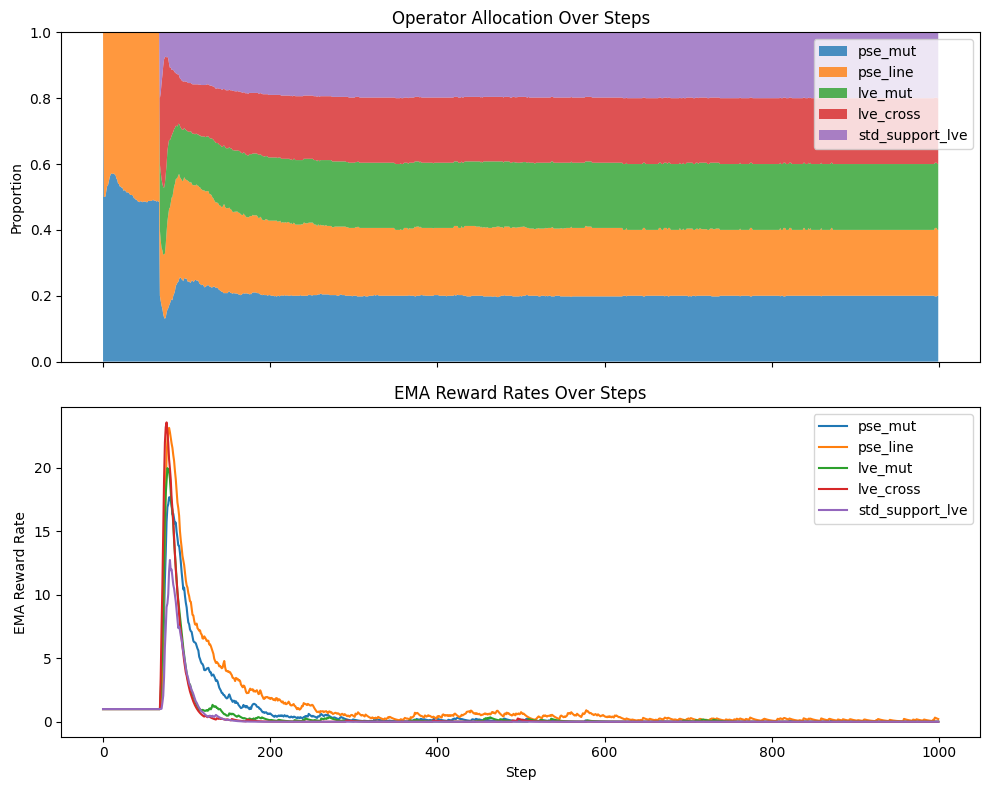

串流輸出內容已截斷至最後 5000 行。
Epoch 10/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0017 | Val Total: 0.0005
Epoch 20/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0017 | Val Total: 0.0005
Epoch 30/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0015 | Val Total: 0.0005
Epoch 40/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0017 | Val Total: 0.0005
Epoch 50/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0016 | Val Total: 0.0005

--- SSLVE Step 547/1000 ---
  Operator ratio - pse_mut: 100/500 (20%), pse_line: 100/500 (20%), lve_mut: 100/500 (20%), lve_cross: 100/500 (20%), std_support_lve: 100/500 (20%)
Collecting: 500/500 [3s elapsed, 0s remaining]
Archive: 5178, Bins: 1735, Coverage: 0.8897, Fitness min/mean/max: 0.00/0.00/0.02
QD-score: 173492.3869
Epoch 10/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0020 | Val Total: 0.0005
Epoch 20/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0020 | Val Total: 0.0005
Epoch 30/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0019 | Val Total: 0.0005
Ep

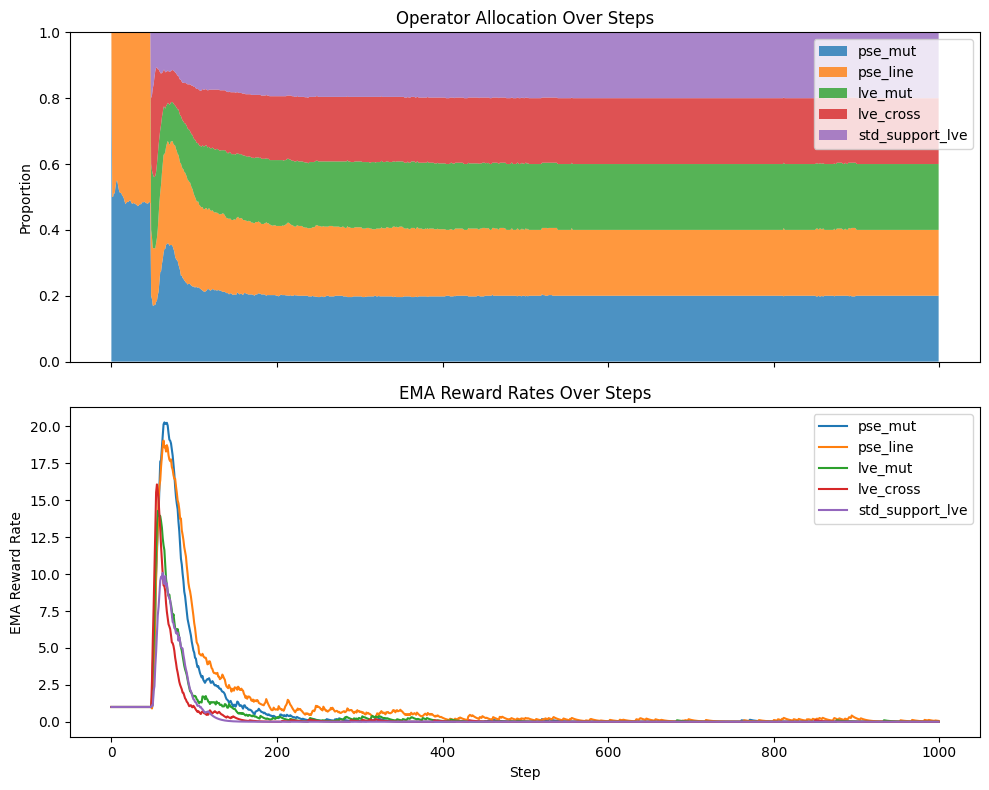

串流輸出內容已截斷至最後 5000 行。
Epoch 10/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0000 | Val Total: 0.0004
Epoch 20/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0000 | Val Total: 0.0004
Epoch 30/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0000 | Val Total: 0.0004
Epoch 40/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0000 | Val Total: 0.0004
Epoch 50/50 | Train Total: 0.0005, Recon: 0.0005, KL: 0.0000 | Val Total: 0.0004

--- SSLVE Step 547/1000 ---
  Operator ratio - pse_mut: 100/500 (20%), pse_line: 103/500 (21%), lve_mut: 99/500 (20%), lve_cross: 99/500 (20%), std_support_lve: 99/500 (20%)
Collecting: 500/500 [3s elapsed, 0s remaining]
Archive: 5122, Bins: 1725, Coverage: 0.8846, Fitness min/mean/max: 0.00/0.00/0.01
QD-score: 172492.5220
Epoch 10/50 | Train Total: 0.0004, Recon: 0.0004, KL: 0.0000 | Val Total: 0.0005
Epoch 20/50 | Train Total: 0.0004, Recon: 0.0004, KL: 0.0000 | Val Total: 0.0005
Epoch 30/50 | Train Total: 0.0004, Recon: 0.0004, KL: 0.0000 | Val Total: 0.0005
Epoch

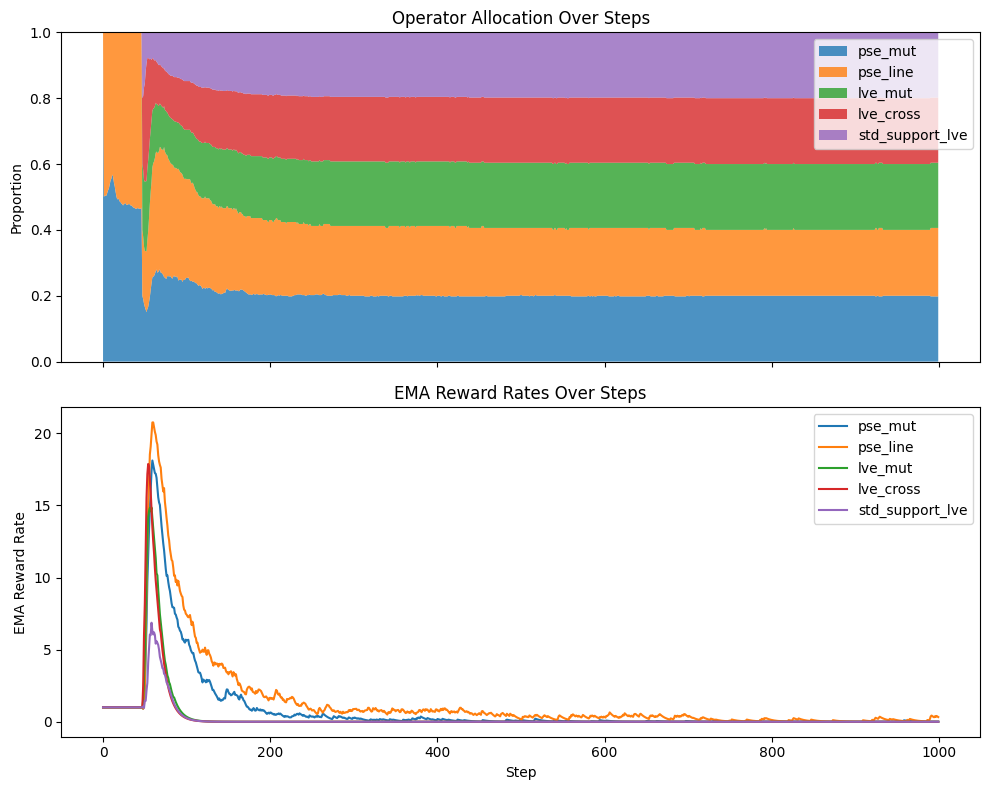

串流輸出內容已截斷至最後 5000 行。
--- SSLVE Step 526/1000 ---
  Operator ratio - pse_mut: 250/500 (50%), pse_line: 250/500 (50%)
Collecting: 500/500 [8s elapsed, 0s remaining]
Archive: 984, Bins: 341, Coverage: 0.1749, Fitness min/mean/max: 0.14/0.15/0.31
QD-score: 34048.6502

--- SSLVE Step 527/1000 ---
  Operator ratio - pse_mut: 250/500 (50%), pse_line: 250/500 (50%)
Collecting: 500/500 [8s elapsed, 0s remaining]
Archive: 986, Bins: 341, Coverage: 0.1749, Fitness min/mean/max: 0.14/0.15/0.31
QD-score: 34048.6910

--- SSLVE Step 528/1000 ---
  Operator ratio - pse_mut: 250/500 (50%), pse_line: 250/500 (50%)
Collecting: 500/500 [8s elapsed, 0s remaining]
Archive: 987, Bins: 342, Coverage: 0.1754, Fitness min/mean/max: 0.14/0.15/0.31
QD-score: 34148.6409

--- SSLVE Step 529/1000 ---
  Operator ratio - pse_mut: 250/500 (50%), pse_line: 250/500 (50%)
Collecting: 500/500 [8s elapsed, 0s remaining]
Archive: 987, Bins: 342, Coverage: 0.1754, Fitness min/mean/max: 0.14/0.15/0.31
QD-score: 34148.7079

---

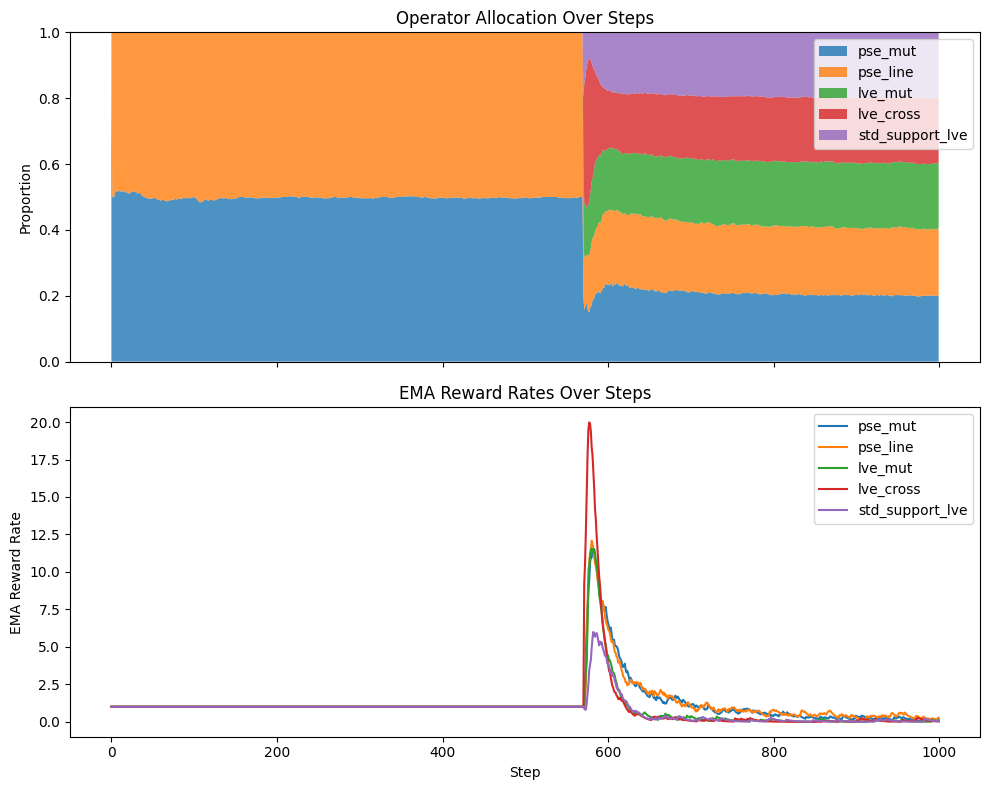

串流輸出內容已截斷至最後 5000 行。
Epoch 10/50 | Train Total: 0.0007, Recon: 0.0006, KL: 0.0089 | Val Total: 0.0007
Epoch 20/50 | Train Total: 0.0006, Recon: 0.0006, KL: 0.0082 | Val Total: 0.0007
Epoch 30/50 | Train Total: 0.0006, Recon: 0.0005, KL: 0.0088 | Val Total: 0.0007
Epoch 40/50 | Train Total: 0.0006, Recon: 0.0005, KL: 0.0091 | Val Total: 0.0007
Epoch 50/50 | Train Total: 0.0006, Recon: 0.0006, KL: 0.0088 | Val Total: 0.0007

--- SSLVE Step 547/1000 ---
  Operator ratio - pse_mut: 102/500 (20%), pse_line: 102/500 (20%), lve_mut: 100/500 (20%), lve_cross: 98/500 (20%), std_support_lve: 98/500 (20%)
Collecting: 500/500 [8s elapsed, 0s remaining]
Archive: 3639, Bins: 1282, Coverage: 0.6574, Fitness min/mean/max: 0.00/0.00/0.03
QD-score: 128194.8681
Epoch 10/50 | Train Total: 0.0007, Recon: 0.0006, KL: 0.0085 | Val Total: 0.0006
Epoch 20/50 | Train Total: 0.0007, Recon: 0.0006, KL: 0.0088 | Val Total: 0.0006
Epoch 30/50 | Train Total: 0.0007, Recon: 0.0006, KL: 0.0087 | Val Total: 0.0006
Epoc

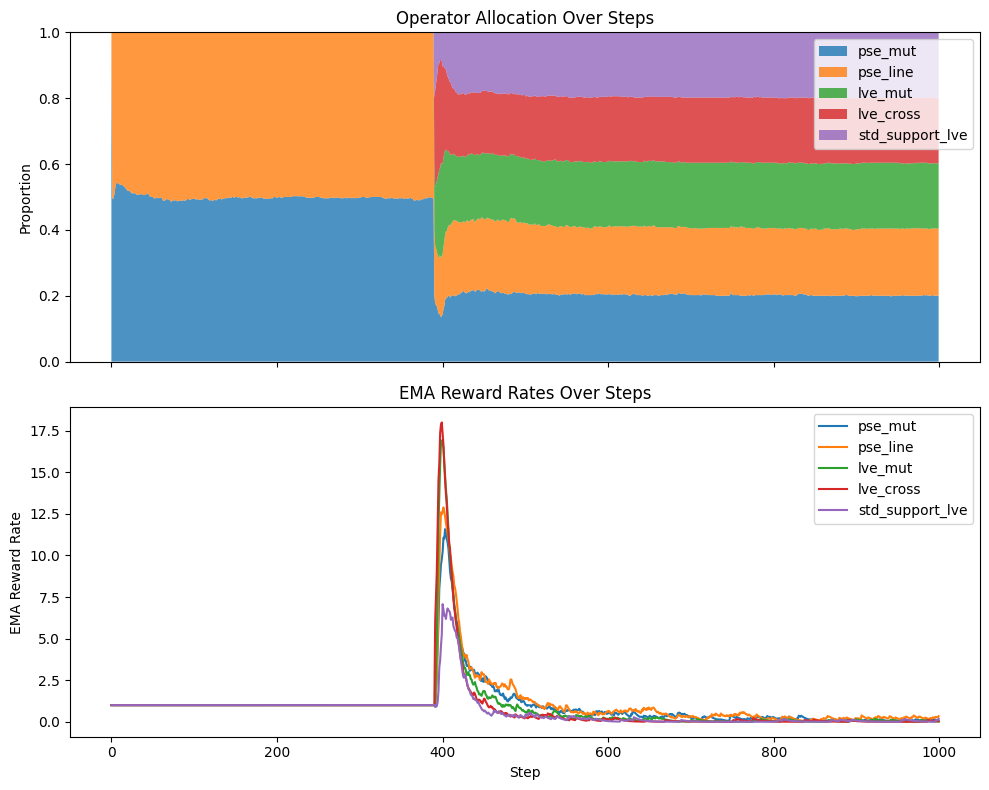

串流輸出內容已截斷至最後 5000 行。
Epoch 10/50 | Train Total: 0.0009, Recon: 0.0009, KL: 0.0021 | Val Total: 0.0009
Epoch 20/50 | Train Total: 0.0009, Recon: 0.0009, KL: 0.0023 | Val Total: 0.0009
Epoch 30/50 | Train Total: 0.0009, Recon: 0.0009, KL: 0.0025 | Val Total: 0.0009
Epoch 40/50 | Train Total: 0.0009, Recon: 0.0009, KL: 0.0023 | Val Total: 0.0009
Epoch 50/50 | Train Total: 0.0009, Recon: 0.0009, KL: 0.0024 | Val Total: 0.0009

--- SSLVE Step 547/1000 ---
  Operator ratio - pse_mut: 112/500 (22%), pse_line: 109/500 (22%), lve_mut: 93/500 (19%), lve_cross: 93/500 (19%), std_support_lve: 93/500 (19%)
Collecting: 500/500 [9s elapsed, 0s remaining]
Archive: 3326, Bins: 1197, Coverage: 0.6138, Fitness min/mean/max: 0.00/0.00/0.17
QD-score: 119695.4471
Epoch 10/50 | Train Total: 0.0009, Recon: 0.0009, KL: 0.0027 | Val Total: 0.0010
Epoch 20/50 | Train Total: 0.0009, Recon: 0.0008, KL: 0.0026 | Val Total: 0.0010
Epoch 30/50 | Train Total: 0.0009, Recon: 0.0009, KL: 0.0023 | Val Total: 0.0010
Epoch

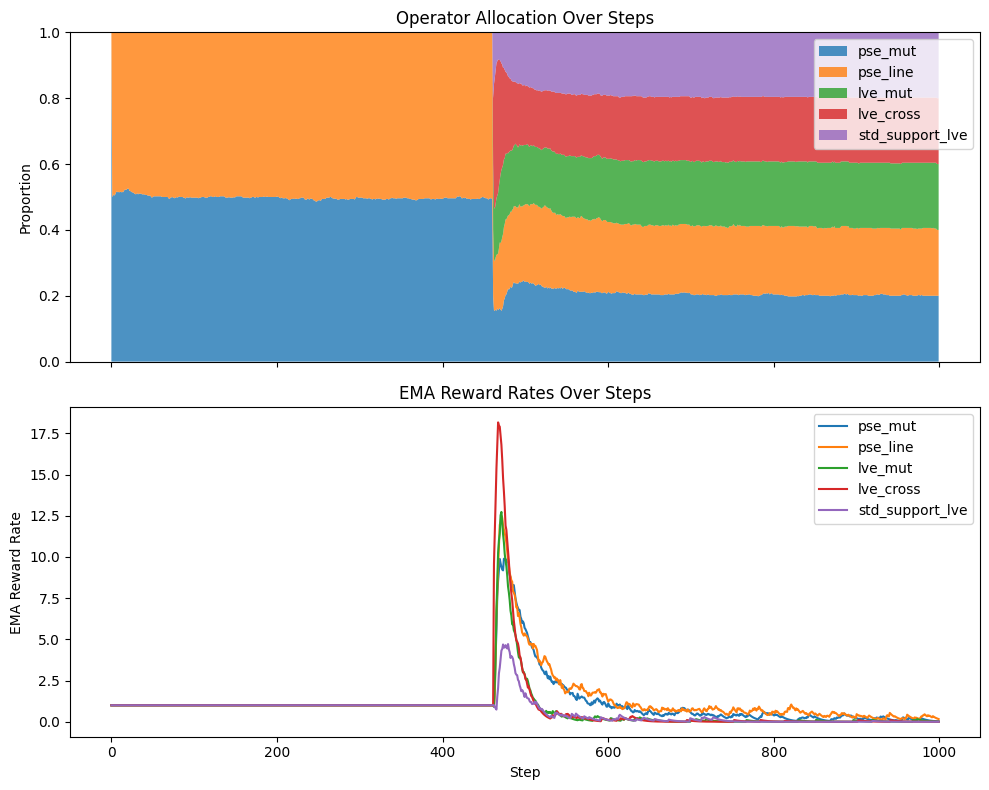

串流輸出內容已截斷至最後 5000 行。
Epoch 50/50 | Train Total: 0.0014, Recon: 0.0014, KL: 0.0004 | Val Total: 0.0014

--- SSLVE Step 227/1000 ---
  Operator ratio - pse_mut: 104/500 (21%), pse_line: 117/500 (23%), lve_mut: 93/500 (19%), lve_cross: 93/500 (19%), std_support_lve: 93/500 (19%)
Collecting: 500/500 [4s elapsed, 0s remaining]
Archive: 4605, Bins: 1577, Coverage: 0.8087, Fitness min/mean/max: 0.03/0.05/0.19
QD-score: 157619.8382
Epoch 10/50 | Train Total: 0.0014, Recon: 0.0014, KL: 0.0004 | Val Total: 0.0012
Epoch 20/50 | Train Total: 0.0014, Recon: 0.0014, KL: 0.0004 | Val Total: 0.0012
Epoch 30/50 | Train Total: 0.0014, Recon: 0.0014, KL: 0.0003 | Val Total: 0.0012
Epoch 40/50 | Train Total: 0.0014, Recon: 0.0014, KL: 0.0004 | Val Total: 0.0012
Epoch 50/50 | Train Total: 0.0014, Recon: 0.0014, KL: 0.0004 | Val Total: 0.0012

--- SSLVE Step 228/1000 ---
  Operator ratio - pse_mut: 104/500 (21%), pse_line: 117/500 (23%), lve_mut: 93/500 (19%), lve_cross: 93/500 (19%), std_support_lve: 93/50

In [ ]:
# ============================================================
# Cell 3: Run All Experiments (4 envs x 3 seeds)
# Each run saves a checkpoint + plots immediately after finishing.
# ============================================================

ENV_CONFIGS = [
    {'name': 'Det_Linear',    'noise_sigma': 0.0,  'n_episodes': 1, 'fitness': 'angle_variance'},
    {'name': 'Unc_Linear',    'noise_sigma': 0.05, 'n_episodes': 3, 'fitness': 'angle_variance'},
    {'name': 'Det_NonLinear', 'noise_sigma': 0.0,  'n_episodes': 1, 'fitness': 'sine_dependency'},
    {'name': 'Unc_NonLinear', 'noise_sigma': 0.05, 'n_episodes': 3, 'fitness': 'sine_dependency'},
]

SEEDS = [42, 123, 456]

FITNESS_FNS = {
    'angle_variance':  lambda info: (np.mean(info['angle_variance'])  if isinstance(info['angle_variance'],  list) else info['angle_variance']),
    'sine_dependency': lambda info: (np.mean(info['sine_dependency']) if isinstance(info['sine_dependency'], list) else info['sine_dependency']),
}

all_results = []

ANGLES_PER_JOINT = END_EFFECTOR_DIM - 1
GENE_DIM = N_JOINTS * ANGLES_PER_JOINT
init_fn = lambda: np.random.uniform(-np.pi, np.pi, GENE_DIM)

train_kwargs = {
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'verbose': True,
}

for env_cfg in ENV_CONFIGS:
    env_name    = env_cfg['name']
    noise_sig   = env_cfg['noise_sigma']
    n_eps       = env_cfg['n_episodes']
    fitness_key = env_cfg['fitness']
    fitness_fn  = FITNESS_FNS[fitness_key]

    for seed in SEEDS:
        print(f'\n========== {env_name} | seed={seed} ==========')

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        collector = PlanarArmCollector(
            n_joints=N_JOINTS,
            end_effector_dim=END_EFFECTOR_DIM,
            noise_sigma=noise_sig,
            n_episodes=n_eps,
        )
        bd = PlanarArmBD_CVT(n_bins=N_BINS, centers=CENTERS, bd_dim=END_EFFECTOR_DIM)
        bm = MAPElitesBM(behavior_descriptor=bd, fitness_fn=fitness_fn, top_k=TOP_K, max_fitness=100)

        # --- Build operators ---
        operators = [
            PSEMut(sigma=PSE_MUT_SIGMA, greedy_mem=GREEDY_MEM),
            PSELine(greedy_mem=GREEDY_MEM),
            LVEMut(sigma=LVE_MUT_SIGMA, greedy_mem=GREEDY_MEM),
            LVECross(greedy_mem=GREEDY_MEM),
        ]

        # --- Build warmup operators ---
        warmup_operators = [
            PSEMut(sigma=PSE_MUT_SIGMA, greedy_mem=GREEDY_MEM),
            PSELine(greedy_mem=GREEDY_MEM),
        ]

        # --- Build latent module ---
        lm = BaseBetaVAE(
            input_dim=GENE_DIM,
            latent_dim=LATENT_DIM,
            hidden_dims=HIDDEN_DIMS,
            beta=BETA,
        )

        # --- Add StandardNormalSupportLVE after latent module is created ---
        operators.append(StandardNormalSupportLVE(lo=STD_SUPPORT_LO, hi=STD_SUPPORT_HI))

        sp = BoltzmannMix(
            agent_class=PlanarArmAgent,
            architecture=GENE_DIM,
            operators=operators,
            warmup_operators=warmup_operators,
            n_total=N_TOTAL,
            warmup_threshold=WARMUP_THRESHOLD,
            ema_alpha=EMA_ALPHA,
            temperature=TEMPERATURE,
            min_proportion=MIN_PROPORTION,
            init_fn=init_fn,
        )

        orchestrator = SSLVE(
            search_phase=sp,
            collector=collector,
            behavior_matching=bm,
            latent_module=lm,
            device=DEVICE,
        )

        orchestrator.run(n_steps=N_STEPS, train_kwargs=train_kwargs)

        # Save checkpoint immediately after this run
        ckpt_path = os.path.join(
            CKPT_BASE_DIR,
            f'LVE_BoltzMix_BetaVAE_ld{LATENT_DIM}_{env_name}_seed{seed}/'
        )
        save_checkpoint(ckpt_path, bm, orchestrator.history, sp=sp, lm=lm)
        print(f'Checkpoint saved: {ckpt_path}')

        # Save plots into checkpoint folder
        orchestrator.plot_history(save_path=ckpt_path + 'plot_history.png')
        sp.plot_allocation(save_path=ckpt_path + 'plot_allocation.png')
        print(f'Plots saved to: {ckpt_path}')

        # Force Drive sync after each run
        from google.colab import drive
        drive.flush_and_unmount()
        drive.mount('/content/drive')
        print('Drive re-synced.')

        # Print results
        f_min, f_mean, f_max = bm.fitness_stats()
        qd  = bm.qd_score()
        cov = bm.coverage()
        print(f'QD-score: {qd:.4f} | Coverage: {cov:.4f} | Best fitness: {f_min:.6f}')

        all_results.append({
            'env': env_name, 'seed': seed,
            'qd_score': qd, 'coverage': cov,
        })

print('\n====== All runs complete ======')